In [60]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sklearn as sk
from scipy.optimize import minimize
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.base import clone

In [61]:
rodar_rn = True
resetar_banco = True

In [62]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\tests_rn\results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")

A pasta já está vazia.


In [63]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

phase = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

for i in range(4):
    data[i]['phases'] = phase[i].values

columns = data[0].columns
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']

In [64]:
#Rede Neural
def run_model(X, y, occ):

    # Modelo 
    base_model = MLPRegressor(
        hidden_layer_sizes=(20,10,5),
        activation='tanh',
        solver='adam',
        max_iter=500,
        random_state=42
    )
    

    # Divisão treino e teste (80%/20%)
    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
 
    model = clone(base_model)

    #Treino
    model.fit(X_train, y_train)
    
    # Predições
    y_pred = model.predict(X)

    #Curva de aprendizado 
    plt.figure(figsize=(8,5))
    plt.plot(model.loss_curve_)
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.title(f'Curva de aprendizado - OCC {occ}')
    plt.grid(True)
    plt.show()

    return y_pred


In [65]:
def save_rn(occ, phase, ns_list):
    path = f'.\\tests_rn\\results\\rn_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({                    

            'TruePhase': phase,
            'PhaseEstimada': ns_list,
        })
        
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({
            'TruePhase': phase,
            'PhaseEstimada': ns_list,

        })

    df.to_csv(f'.\\tests_rn\\results\\rn_{occ}.csv', index=False)

In [66]:
def run_algorithm(data):

    #reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    #Para cada ocupação e cada tolerância, roda o método de Nelder-Mead e salva os resultados
    if rodar_rn:
        k = 0
        for i in range(4):
            samples_data = np.array(data[i][columns[0:7]])
            phases_data = np.array(data[i][columns[8]])

            sample4 = run_model(samples_data, phases_data, occ_name[i])
            save_rn(occ_name[i], phases_data, sample4)
            k +=1
            print(f'Occupancy {occ_name[i][3:]} and tolerance {1} done, lacking {4 - k} combinations')

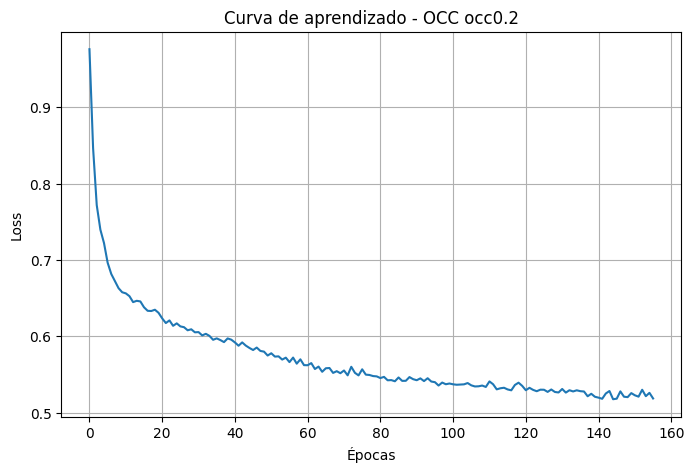

Occupancy 0.2 and tolerance 1 done, lacking 3 combinations


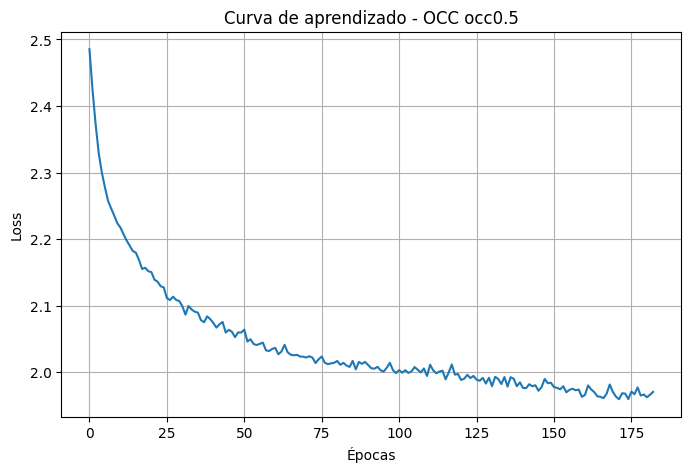

Occupancy 0.5 and tolerance 1 done, lacking 2 combinations


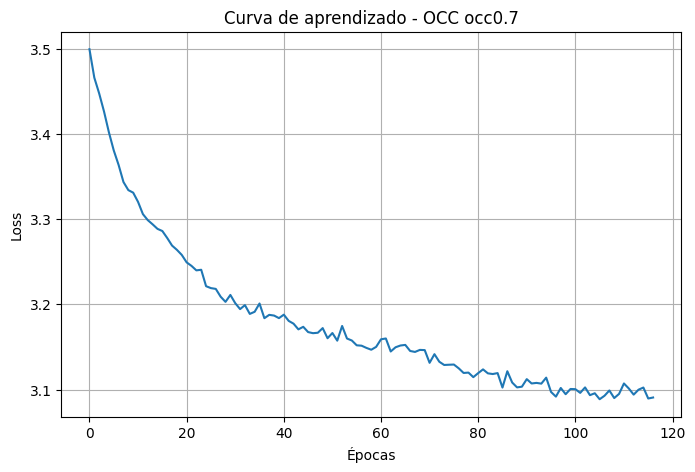

Occupancy 0.7 and tolerance 1 done, lacking 1 combinations


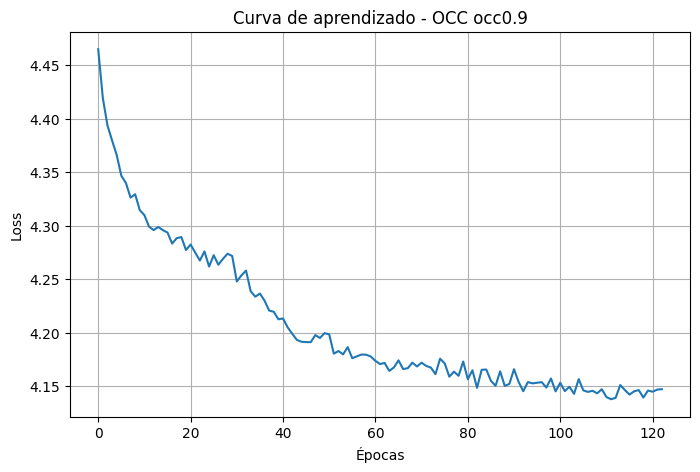

Occupancy 0.9 and tolerance 1 done, lacking 0 combinations


In [67]:
run_algorithm(data)

In [68]:
def load_results():
    resultados = [
        pd.read_csv(r'.\tests_rn\results\rn_occ0.2.csv'),
        pd.read_csv(r'.\tests_rn\results\rn_occ0.5.csv'),
        pd.read_csv(r'.\tests_rn\results\rn_occ0.7.csv'),
        pd.read_csv(r'.\tests_rn\results\rn_occ0.9.csv'),
    ]
    return resultados

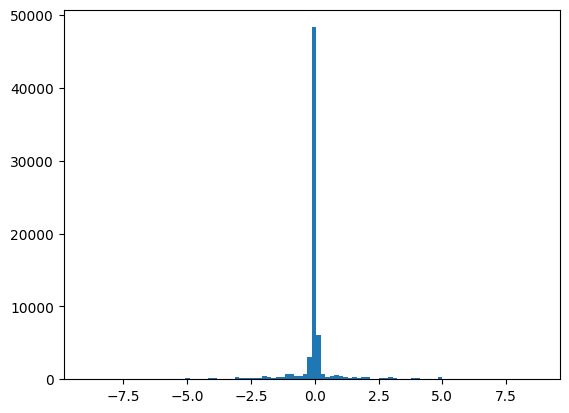

Mean error for occupancy occ0.2: -0.05863480352799556


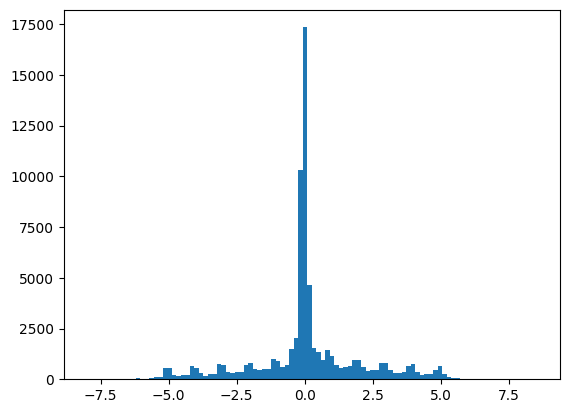

Mean error for occupancy occ0.5: 0.07972777020001719


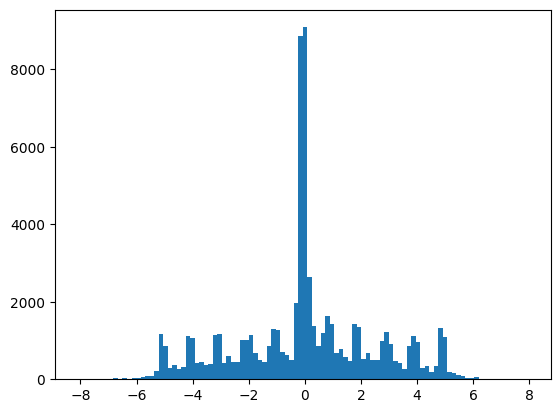

Mean error for occupancy occ0.7: 0.007691803377329034


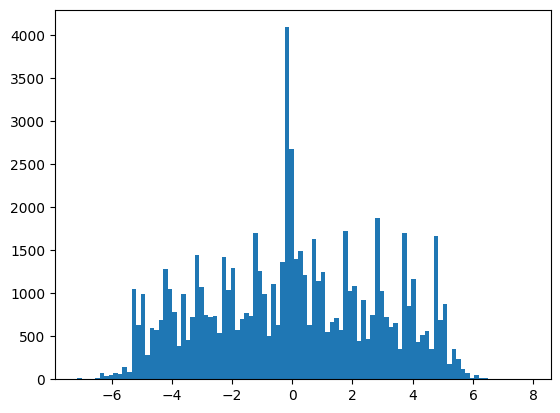

Mean error for occupancy occ0.9: -0.009639939917809296


In [72]:
df = load_results()

for i in range(len(df)):
    phase_error = df[i]['TruePhase'] - df[i]['PhaseEstimada']
    plt.hist(phase_error, bins=100)
    plt.show()
    print(f'Mean error for occupancy {occ_name[i]}: {np.mean(phase_error)}')

In [70]:
def linearfit(real, estimada, name, occ):
    a, b = np.polyfit(real, estimada, 1)
    x_fit = np.linspace(real.min(), real.max(), 100)
    y_fit = a*x_fit + b
    plt.scatter(real, estimada, alpha=0.2, s=15, label='Predições')

# ideal        
    plt.plot(x_fit, x_fit, '--', color='black', linewidth=3, label='Ideal')

# fit
    plt.plot(x_fit, y_fit, '-', color='red', linewidth=3, label=f'Fit: y={a:.2f}x + {b:.2f}')

    plt.xlabel('Phase Real')
    plt.ylabel('Phase Predita')
    plt.title(f'{name} Real vs Predito - {occ}')
    plt.legend()
    plt.grid(True)
    plt.show()

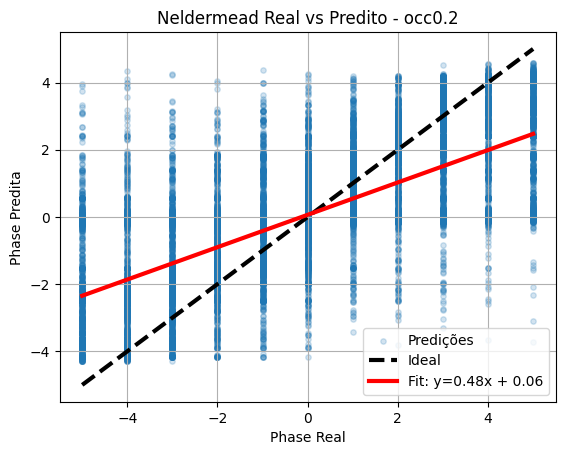

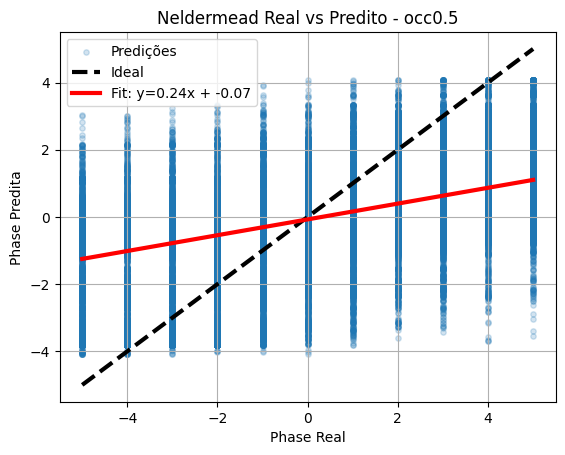

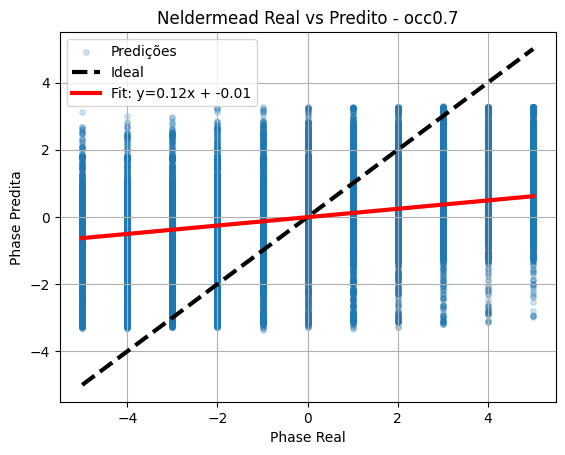

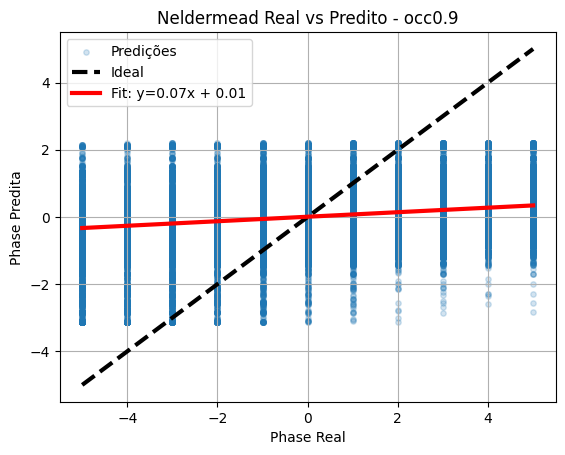

In [71]:
df = load_results()

for i in range(len(df)):
    linearfit(df[i]['TruePhase'], df[i]['PhaseEstimada'], 'Neldermead', occ_name[i])